$\LARGE{EN3160\ Assignment\ 1\ on\ Intensity\ Transformations\ and\ Neighborhood\ Filtering}$

$\Large{Index: 230544C}\\
\Large{Name: Rathnayake\ M.\ A.\ G.\ K.\ N.}$

In [8]:
#Importing the libaries
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

$Q1)$

In [256]:
#Defining the funciton for the intenstity tranformation
def intensity_transform(im, breakpoints):

    #Selecting the input and output intesities from the breakpoints
    x = breakpoints[:, 0] #Input values
    y = breakpoints[:, 1] #Output values

    #Matching the breakpoints and creating a function
    tranformation = np.interp(im, x, y)

    return tranformation

#Importin the initial image
im_orig = cv.imread('Emma.jpg', cv.IMREAD_GRAYSCALE)

#Applying transformation
breakpoints = np.array([[0, 0], [50, 50], [50, 100], [150,255], [150, 150], [255, 255]])
im_transformed = intensity_transform(im_orig, breakpoints)

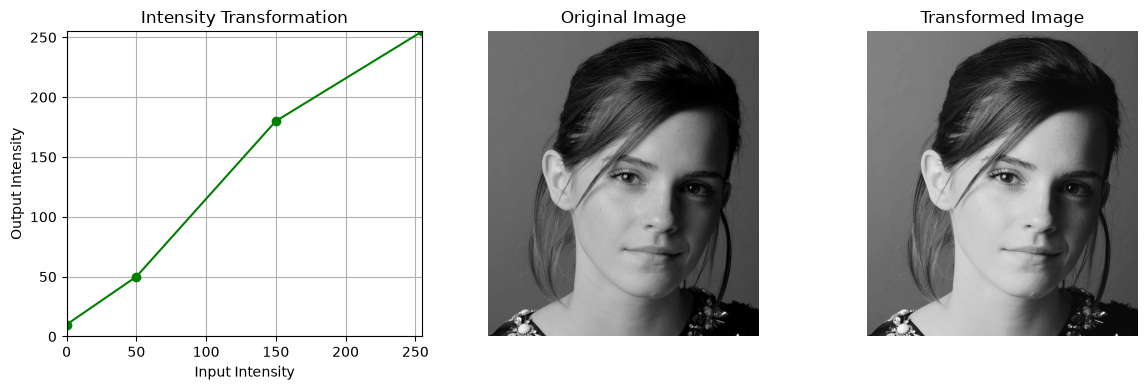

In [262]:
#Trying different breakpoints to get a visually pleasing output
breakpoints = np.array([[0, 10], [50, 50], [150, 180], [255, 255]])
im_transformed = intensity_transform(im_orig, breakpoints)

#Plotting
fig, ax = plt.subplots(1, 3, figsize= (12, 4))

#Tranformation function
ax[0].plot(breakpoints[:, 0], breakpoints[:, 1], marker='o', color= 'green')
ax[0].set_title('Intensity Transformation')
ax[0].set_xlabel('Input Intensity')
ax[0].set_ylabel('Output Intensity')
ax[0].set_xlim(0, 255)
ax[0].set_ylim(0, 255)
ax[0].grid()

#Original image
ax[1].imshow(im_orig, cmap = 'gray', vmin = 0, vmax = 255)
ax[1].set_title('Original Image')
ax[1].axis('off')

#Transformed image
ax[2].imshow(im_transformed, cmap ='gray', vmin = 0, vmax = 255)
ax[2].set_title('Transformed Image')
ax[2].axis('off')

plt.tight_layout()
plt.show()


$Q2)$

In [263]:
#Importing brain image
im_brain = cv.imread('Brain.png', cv.IMREAD_GRAYSCALE)

#Caluclating histogram
hist = cv.calcHist([im_brain], [0], None, [256], [0,256])

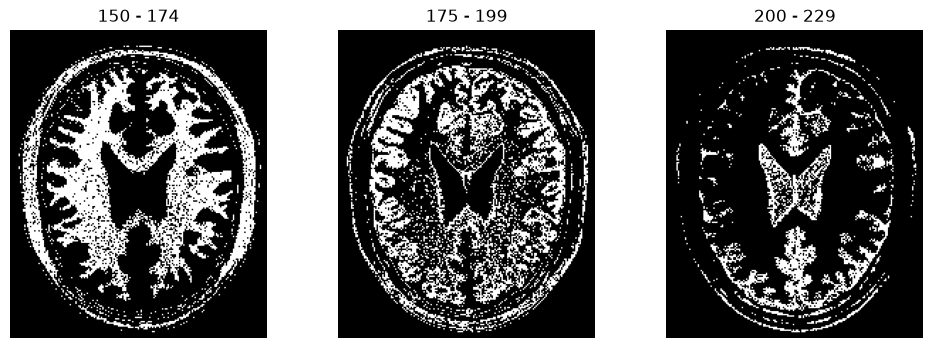

In [264]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# Different candidate intensity ranges
range1 = ((im_brain >= 150) & (im_brain < 175))
range2 = ((im_brain >= 175) & (im_brain < 200))
range3 = ((im_brain >= 200) & (im_brain < 230))

ax[0].imshow(range1, cmap='gray')
ax[0].set_title('150 - 174')

ax[1].imshow(range2, cmap='gray')
ax[1].set_title('175 - 199')

ax[2].imshow(range3, cmap='gray')
ax[2].set_title('200 - 229')

for a in ax:
    a.axis('off')

plt.show()

$Q2)\ a)$

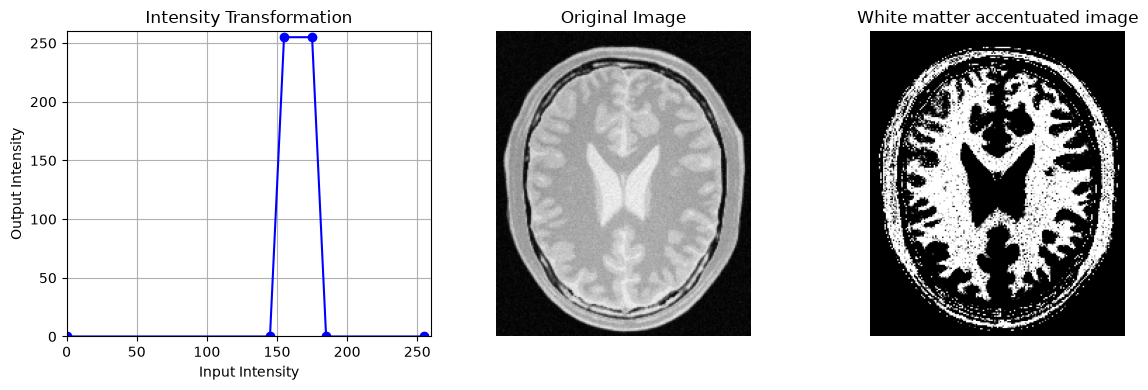

In [265]:
#Creating breakpoints for the white matter attenuation
breakpoints_white_matter_accentuation = np.array([[0, 0], [145, 0], [155, 255], [175, 255], [185, 0], [255, 0]])

im_white_matter_accentuated = intensity_transform(im_brain, breakpoints_white_matter_accentuation)

#Plotting
fig, ax = plt.subplots(1, 3, figsize= (12, 4))

#Tranformation function
ax[0].plot(breakpoints_white_matter_accentuation[:, 0], breakpoints_white_matter_accentuation[:, 1], marker='o', color= 'blue')
ax[0].set_title('Intensity Transformation')
ax[0].set_xlabel('Input Intensity')
ax[0].set_ylabel('Output Intensity')
ax[0].set_xlim(0, 260)
ax[0].set_ylim(0, 260)
ax[0].grid()

#Original image
ax[1].imshow(im_brain, cmap = 'gray', vmin = 0, vmax = 255)
ax[1].set_title('Original Image')
ax[1].axis('off')

#Transformed image
ax[2].imshow(im_white_matter_accentuated, cmap ='gray', vmin = 0, vmax = 255)
ax[2].set_title('White matter accentuated image')
ax[2].axis('off')

plt.tight_layout()
plt.show()


$Q2)\ b)$

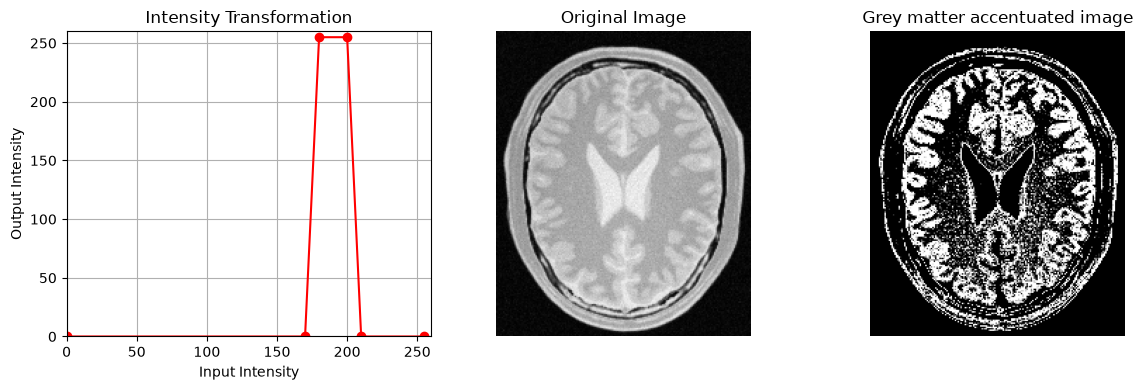

In [266]:
#Creating breakpoints for the grey matter attenuation
breakpoints_grey_matter_accentuation = np.array([[0, 0], [170, 0], [180, 255], [200, 255], [210, 0], [255, 0]])

im_grey_matter_accentuated = intensity_transform(im_brain, breakpoints_grey_matter_accentuation)

#Plotting
fig, ax = plt.subplots(1, 3, figsize= (12, 4))

#Tranformation function
ax[0].plot(breakpoints_grey_matter_accentuation[:, 0], breakpoints_grey_matter_accentuation[:, 1], marker='o', color= 'red')
ax[0].set_title('Intensity Transformation')
ax[0].set_xlabel('Input Intensity')
ax[0].set_ylabel('Output Intensity')
ax[0].set_xlim(0, 260)
ax[0].set_ylim(0, 260)
ax[0].grid()

#Original image
ax[1].imshow(im_brain, cmap = 'gray', vmin = 0, vmax = 255)
ax[1].set_title('Original Image')
ax[1].axis('off')

#Transformed image
ax[2].imshow(im_grey_matter_accentuated, cmap ='gray', vmin = 0, vmax = 255)
ax[2].set_title('Grey matter accentuated image')
ax[2].axis('off')

plt.tight_layout()
plt.show()

$Q3)\ a)$

The used gamma value is 0.7


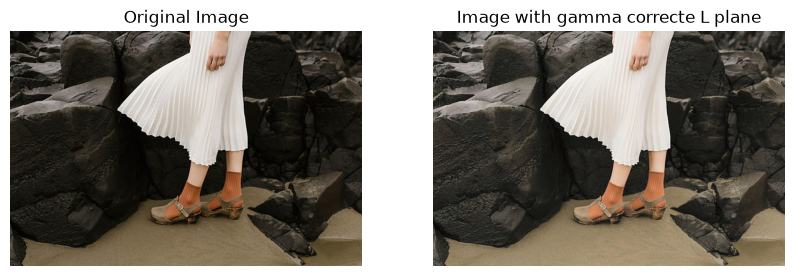

In [296]:
#Importing the image
im_orig = cv.imread('Legs.jpg')

#Converting the image to L*a*b* 
im_lab = cv.cvtColor(im_orig, cv.COLOR_BGR2LAB)

#Splitting the three channels
L, a, b = cv.split(im_lab)

# Gamma correction lookup table
gamma = 0.7

table = np.array([(i / 255.0) ** gamma * 255.0 for i in np.arange(256)]).astype(np.uint8)

#Applying gamma correction to the L channel
L_gamma = cv.LUT(L, table)

#Merging back
im_lab_L_gamma = cv.merge([L_gamma, a, b])

#Converting the colour space back to BGR
im_L_gamma = cv.cvtColor(im_lab_L_gamma, cv.COLOR_LAB2BGR)

#To display using matplotlib these need to converted into RGB
im_rgb = cv.cvtColor(im_orig, cv.COLOR_BGR2RGB)
im_L_gamma_rgb = cv.cvtColor(im_L_gamma, cv.COLOR_BGR2RGB)

#Pritning the gamma value
print("The used gamma value is", gamma)

#Display
fig, ax = plt.subplots(1, 2, figsize = (10, 5))

ax[0].imshow(im_rgb)
ax[0].set_title('Original Image')

ax[1].imshow(im_L_gamma_rgb)
ax[1].set_title('Image with gamma correcte L plane')

for a in ax:
    a.axis('off')

plt.show()

$Q3)\ b)$

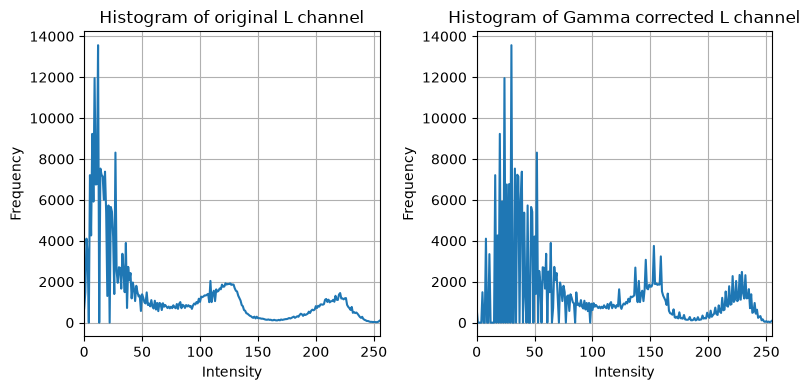

In [297]:
# Histograms of L channel before and after gamma correction
hist_L_orig = cv.calcHist([L], [0], None, [256], [0, 256])
hist_L_gamma = cv.calcHist([L_gamma], [0], None, [256], [0, 256])

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].plot(hist_L_orig)
ax[0].set_title('Histogram of original L channel')
ax[0].set_xlabel('Intensity')
ax[0].set_ylabel('Frequency')
ax[0].set_xlim(0, 255)
ax[0].grid()

ax[1].plot(hist_L_gamma)
ax[1].set_title('Histogram of Gamma corrected L channel')
ax[1].set_xlabel('Intensity')
ax[1].set_ylabel('Frequency')
ax[1].set_xlim(0, 255)
ax[1].grid()

plt.tight_layout()
plt.show()

$Q4)\ a)$

In [303]:
#Importing the image
im_4 = cv.imread('SpiderMan.jpg')

#Converting into HSV planes
im_4_HSV = cv.cvtColor(im_4, cv.COLOR_BGR2HSV)

#Splitting the channels
H, S, V = cv.split(im_4_HSV)

$Q4)\ b)$

In [323]:
# Applying the transformation
a = 0.5
sigma = 70

#Input saturation intensities
x = np.arange(256, dtype=np.float32)

#Vibrance transformation
y = x + a * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2))

#Limiting the output to 255
y = np.minimum(y, 255)

#Creating the lookup table
table = y.astype(np.uint8)

#Applying transformation to the saturation plane
new_S = cv.LUT(S, table)

$Q4)\ c)$

In [324]:
print("Visually pleasing a value is",a)

Visually pleasing a value is 0.5


$Q4)\ d)$

In [325]:
#Combining the 3 channels to see the final image again
im_4_new = cv.merge([H, new_S, V])

#BGR image
im_4_new_BGR = cv.cvtColor(im_4_new, cv.COLOR_HSV2BGR)

#RGB image
im_4_new_RGB = cv.cvtColor(im_4_new_BGR, cv.COLOR_BGR2RGB)

$Q4)\ e)$

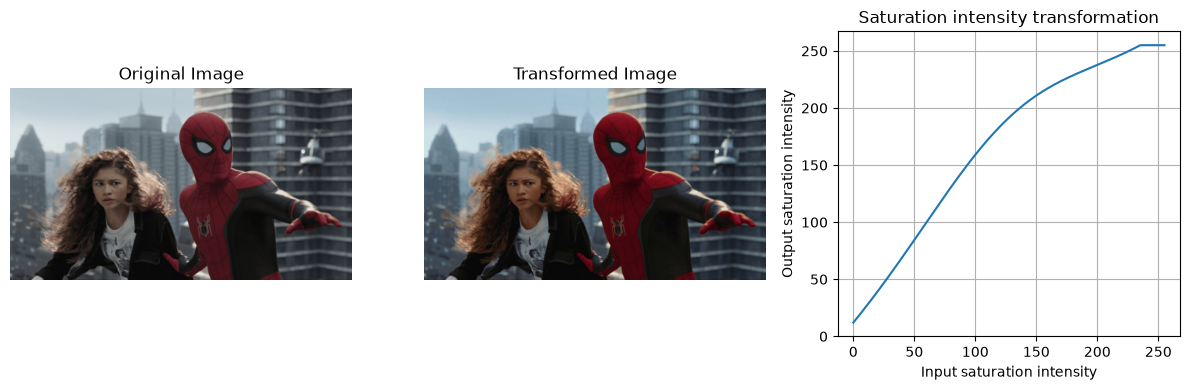

In [327]:
fig, ax = plt.subplots(1, 3, figsize= (12, 4))

ax[0].imshow(cv.cvtColor(im_4, cv.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(im_4_new_RGB)
ax[1].set_title('Transformed Image')
ax[1].axis('off')

ax[2].plot(x, y)
ax[2].set_xlabel('Input saturation intensity')
ax[2].set_ylabel('Output saturation intensity')
ax[2].set_title('Saturation intensity transformation')
ax[2].grid()

plt.tight_layout()
plt.show()

$Q5)$

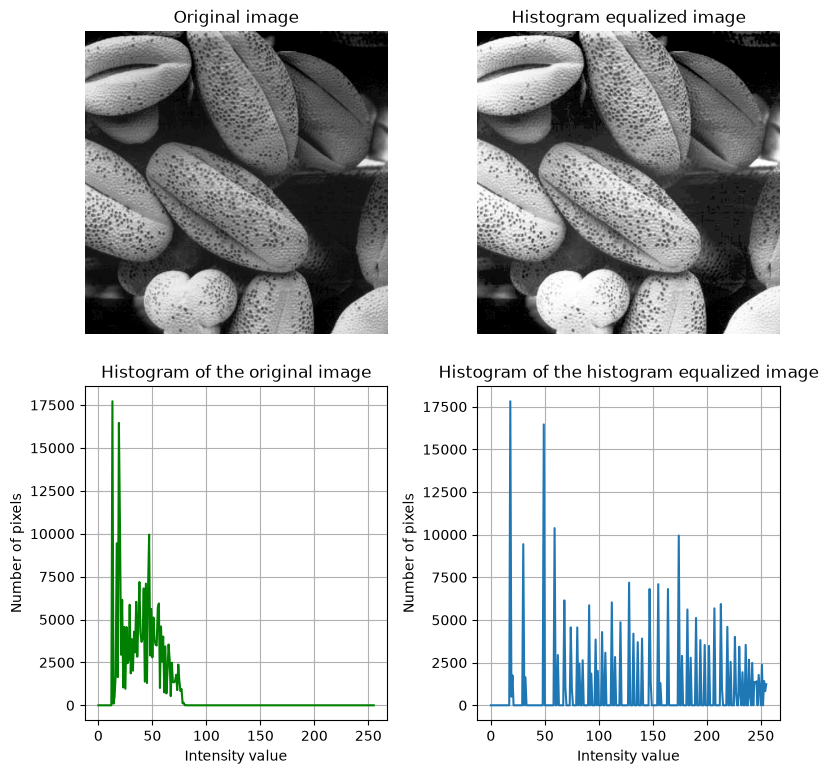

In [197]:
#Importing the image
im_5 = cv.imread('SeaShells.png', cv.IMREAD_GRAYSCALE)

#Calculating the histogram
im_5_hist,im_5_bins = np.histogram(im_5.ravel(),256,[0,256])

#Funtion for histogram equilization
def hist_eq(image):

    #Calculating histogram
    hist,bins = np.histogram(image.ravel(),256,[0,256])

    #Normalizing
    normalized_hist = hist/ image.size

    #Cumulative distribution function
    cdf = np.cumsum(normalized_hist)

    #Tranformation
    tranform = np.round(255 * cdf).astype(np.uint8)

    #Euqilizing the image
    eq_image = tranform[image]

    return eq_image

#Applying the function
im_5_hist_eqd = hist_eq(im_5)

#Calulating the new histogram
im_5_hist_eqd_hist,im_5_hist_eqd_bins = np.histogram(im_5_hist_eqd.ravel(),256,[0,256])
    
fig, ax = plt.subplots(2, 2, figsize=(8, 8))

ax[0, 0].imshow(im_5, cmap='grey')
ax[0, 0].set_title('Original image')
ax[0, 0].axis('off')

ax[0, 1].imshow(im_5_hist_eqd, cmap='grey')
ax[0, 1].set_title('Histogram equalized image')
ax[0, 1].axis('off')

ax[1, 0].plot(im_5_hist, color='green')
ax[1, 0].set_title('Histogram of the original image')
ax[1, 0].set_xlabel('Intensity value')
ax[1, 0].set_ylabel('Number of pixels')
ax[1, 0].grid()

ax[1, 1].plot(im_5_hist_eqd_hist)
ax[1, 1].set_title('Histogram of the histogram equalized image')
ax[1, 1].set_xlabel('Intensity value')
ax[1, 1].set_ylabel('Number of pixels')
ax[1, 1].grid()

plt.tight_layout()
plt.show()

$Q6)\ a)$

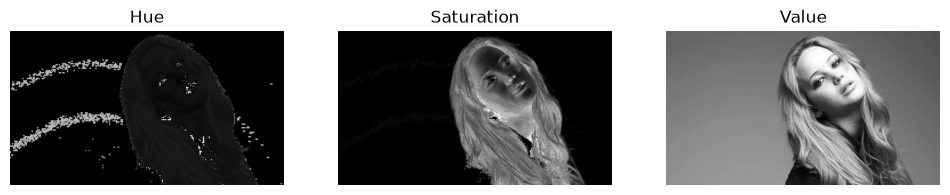

In [274]:
#Importing the image
im_6 = cv.imread('Jennifer.png')

#Seprating the H, S, V planes
H, S, V = cv.split(cv.cvtColor(im_6, cv.COLOR_BGR2HSV))

#Displaying
fig, ax = plt.subplots(1, 3, figsize= (12, 4))

ax[0].imshow(H, cmap='grey')
ax[0].set_title('Hue')

ax[1].imshow(S, cmap='grey')
ax[1].set_title('Saturation')

ax[2].imshow(V, cmap='grey')
ax[2].set_title('Value')

for a in ax:
    a.axis('off')

$Q6)\ b)Best\ plane\ is\ the\ saturation\ plane.\ Because\ it\ is\ the\ only\ plane\ where\ Jennifer\ is\ mostly\ bright\ compared\ to\ the\ background.$

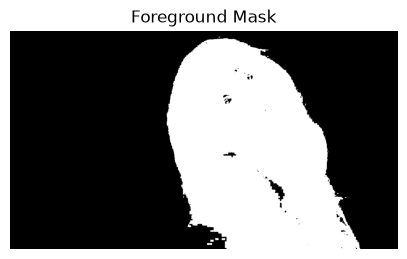

In [ ]:
#BEcause of the dark backgrounds selecting the threshold as 15 (a darker value)
threshold = 15

#Extracting the mask
_, mask = cv.threshold(S, threshold, 255, cv.THRESH_BINARY)

#Dsiplaying the mask
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(mask, cmap='gray')
ax.set_title('Foreground Mask')
ax.axis('off')
plt.show()

$Q6)\ c)$

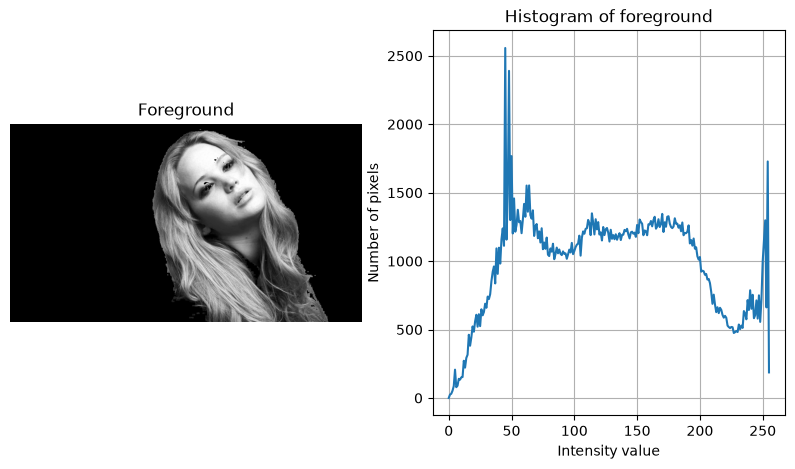

In [276]:
#Obtaining foreground
foreground = cv.bitwise_and(V, V, mask=mask)

#Calculating histogram
foreground_pixels = V[mask == 255]
foreground_hist, foreground_bins = np.histogram(foreground_pixels, 256, [0,256])

#Dsiplaying the mask
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(foreground, cmap='gray')
ax[0].set_title('Foreground')
ax[0].axis('off')

ax[1].plot(foreground_hist)
ax[1].set_title('Histogram of foreground')
ax[1].set_xlabel('Intensity value')
ax[1].set_ylabel('Number of pixels')
ax[1].grid()

plt.show()


$Q6)\ d)$

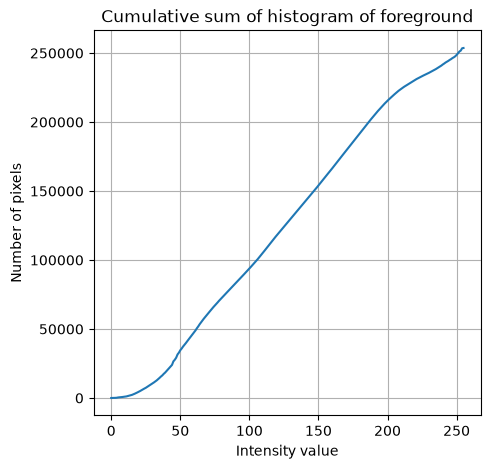

In [277]:
#Obtaining the cumulative sume of the histogram
cdf = np.cumsum(foreground_hist)

fig, ax = plt.subplots(1, 1, figsize=(5,5))

ax.plot(cdf)
ax.set_title('Cumulative sum of histogram of foreground')
ax.set_xlabel('Intensity value')
ax.set_ylabel('Number of pixels')
ax.grid()

plt.show()


$Q6)\ e)$

In [278]:
#Equation from slides
L = 256
foreground_size = foreground_pixels.size
t = np.array([(L-1)/(foreground_size)*cdf[k] for k in range(256)])

t = np.round(t).astype(np.uint8)

#Applying equalization for the foreground
hist_eqd_foreground = np.zeros_like(V)
hist_eqd_foreground[mask == 255] = t[V[mask == 255]]


$Q6)\ f)$

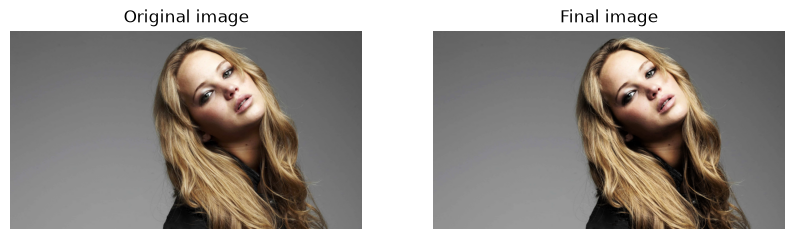

In [279]:
#Extracting the background
background = cv.bitwise_and(V, V, mask=cv.bitwise_not(mask))

#Combining the background with histogram equalized foreground
final_V = cv.add(background, hist_eqd_foreground)

#Recombining H S V planes
final_HSV = cv.merge([H, S, final_V])

#Converting to RGB for display
final_BGR = cv.cvtColor(final_HSV, cv.COLOR_HSV2BGR)
final_RGB = cv.cvtColor(final_BGR, cv.COLOR_BGR2RGB)

#Dsiplaying the mask
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(cv.cvtColor(im_6, cv.COLOR_BGR2RGB))
ax[0].set_title('Original image')
ax[0].axis('off')

ax[1].imshow(final_RGB)
ax[1].set_title('Final image')
ax[1].axis('off')
plt.show()

$Q7)\ a)$

In [280]:
#Importing image
im_7 = cv.imread('Albert.png', cv.IMREAD_GRAYSCALE)

#Sobel filter kernal
sobel = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])

#Existing filter2D function
im_7_part_a = cv.filter2D(im_7, cv.CV_64F, sobel)

$Q7)\ b)$

In [281]:
#Implementing from the scratch
#Creating an empty output image
im_7_part_b = np.zeros_like(im_7, dtype=np.float64)

#Getting row and column number
rows, cols = im_7.shape

#Going over the image
for i in range(1, rows - 1):
    for j in range(1, cols - 1):

        #Extracting the 3 by 3 neighborhood
        region = im_7[i-1:i+2, j-1:j+2]

        #Element wise multiplication and summation
        im_7_part_b[i, j] = np.sum(region * sobel)

$Q7)\ c)$

In [282]:
#Using the outer product to create the kernal
vertical = np.array([1, 2, 1], dtype=np.float64)
horizontal = np.array([1, 0, -1], dtype=np.float64)

#Applying the horizontal 1D filter
temp = cv.filter2D(im_7, cv.CV_64F, horizontal.reshape(1, 3))

#Applying the vertical 1D filter
im_7_part_c = cv.filter2D(temp, cv.CV_64F, vertical.reshape(3, 1))

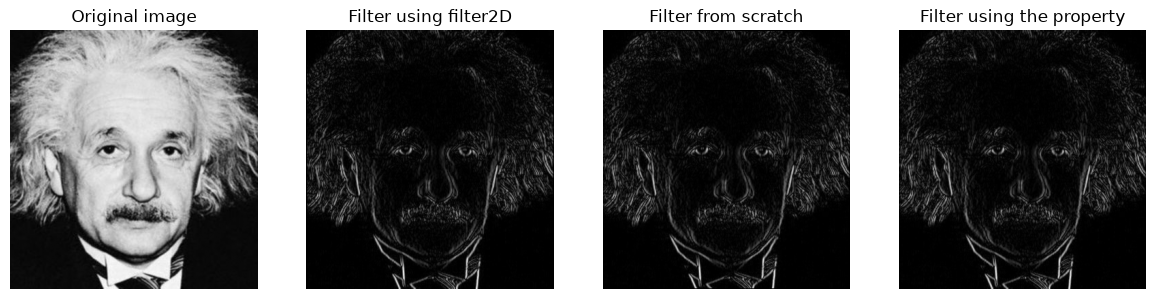

In [283]:
#Displaying the pictures
fig, ax = plt.subplots(1, 4, figsize=(12, 3))

ax[0].imshow(im_7, cmap='grey')
ax[0].set_title('Original image')

ax[1].imshow(np.abs(im_7_part_a), cmap='grey')
ax[1].set_title('Filter using filter2D')

ax[2].imshow(np.abs(im_7_part_b), cmap='grey')
ax[2].set_title('Filter from scratch')

ax[3].imshow(np.abs(im_7_part_c), cmap='grey')
ax[3].set_title('Filter using the property')

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()


$Q8)$

Original large image shape: (112, 200, 3)
Nearest-neighbor shape: (112, 200, 3)
Bilinear interpolation shape: (112, 200, 3)
Normalized SSD for nearest-neighbor: 0.009599429217788839
Normalized SSD for bilinear interpolation: 0.007710873190589466


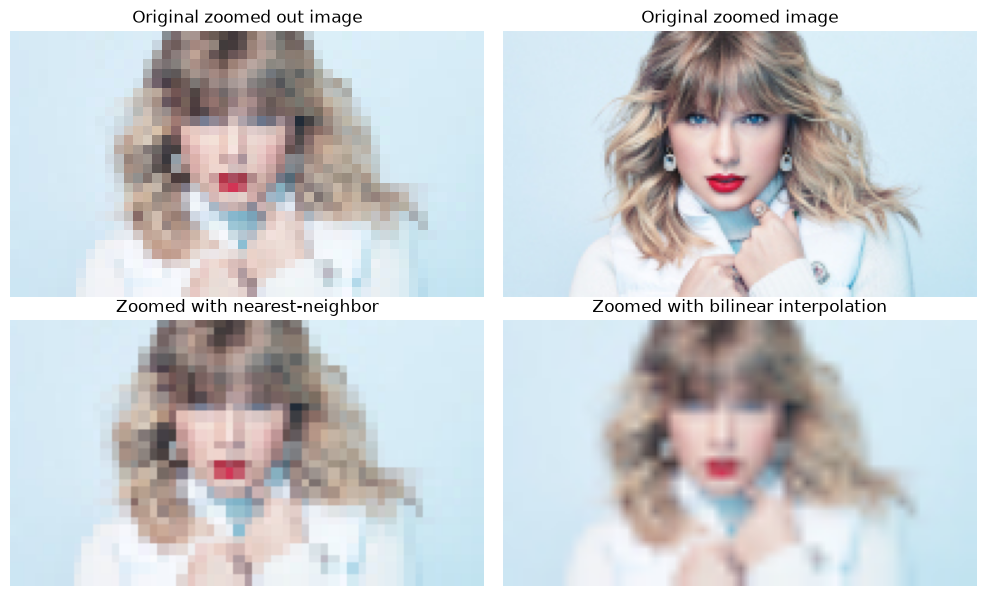

In [ ]:
#Defining the function
def zoom_image(image, scale, method='nearest'):

    #Getting the height and width
    h, w = image.shape[:2]

    #New height and width after scaling
    new_h = int(h * scale)
    new_w = int(w * scale)

    #Creating a blank canvas to store pixel values after zooming
    zoomed = np.zeros((new_h, new_w, image.shape[2]), dtype=image.dtype)

    if method == 'nearest':

        for i in range(new_h):
            for j in range(new_w):

                #Inverse mapping
                src_y = i / scale
                src_x = j / scale

                #Picking the nearest value
                nearest_y = int(round(src_y))
                nearest_x = int(round(src_x))

                #Avoiding errors by going outside the image
                nearest_y = min(nearest_y, h - 1)
                nearest_x = min(nearest_x, w - 1)

                #Assigning
                zoomed[i, j] = image[nearest_y, nearest_x]

    elif method == 'bilinear':

        for i in range(new_h):
            for j in range(new_w):

                #Inverse mapping
                src_y = i / scale
                src_x = j / scale

                #Finding the four pixels around
                y1 = int(np.floor(src_y))
                x1 = int(np.floor(src_x))

                y2 = min(y1 + 1, h - 1)
                x2 = min(x1 + 1, w - 1)

                #Measuring the distance of the zoomed pixel from the found four pixels
                dy = src_y - y1
                dx = src_x - x1

                #Linear interpolation
                top = (1 - dx) * image[y1, x1] + dx * image[y1, x2]
                bottom = (1 - dx) * image[y2, x1] + dx * image[y2, x2]

                value = (1 - dy) * top + dy * bottom

                #Assigning
                zoomed[i, j] = np.clip(value, 0, 255)

    return zoomed

#Importing the small image
im_8 = cv.imread('Taylor_zoomed_out.jpg')

#Importing the large image
im_8_zoomed = cv.imread('Taylor_zoomed.jpg')

#Zooming scale
s = 4

#(a) nearest-neighbor zoom
im_8_nearest_neighbor = zoom_image(im_8, s, 'nearest')

#(b) bilinear interpolation
im_8_bilinear_interpolation = zoom_image(im_8, s, 'bilinear')

# Function for calculating the normalized SSD
def normalized_ssd(original, reconstructed):

    #Converting to float to avoid overflow during subtraction and squaring
    original = original.astype(np.float64)
    reconstructed = reconstructed.astype(np.float64)

    #Calculating the sum of squared differences
    ssd = np.sum((original - reconstructed) ** 2)

    #Normalizing using the energy of the original image
    normalized_ssd = ssd / np.sum(original ** 2)

    return normalized_ssd

#Checking whether the image sizes are equal
print("Original large image shape:", im_8_zoomed.shape)
print("Nearest-neighbor shape:", im_8_nearest_neighbor.shape)
print("Bilinear interpolation shape:", im_8_bilinear_interpolation.shape)

# Calculating normalized SSD
nearest_ssd = normalized_ssd(im_8_zoomed, im_8_nearest_neighbor)
bilinear_ssd = normalized_ssd(im_8_zoomed, im_8_bilinear_interpolation)

# Displaying the results
print("Normalized SSD for nearest-neighbor:", nearest_ssd)
print("Normalized SSD for bilinear interpolation:", bilinear_ssd)

#Displaying
fig, ax = plt.subplots(2, 2, figsize=(10, 6))

ax[0, 0].imshow(cv.cvtColor(im_8, cv.COLOR_BGR2RGB))
ax[0, 0].set_title('Original zoomed out image')

ax[0, 1].imshow(cv.cvtColor(im_8_zoomed, cv.COLOR_BGR2RGB))
ax[0, 1].set_title('Original zoomed image')

ax[1, 0].imshow(cv.cvtColor(im_8_nearest_neighbor, cv.COLOR_BGR2RGB))
ax[1, 0].set_title('Zoomed with nearest-neighbor')

ax[1, 1].imshow(cv.cvtColor(im_8_bilinear_interpolation, cv.COLOR_BGR2RGB))
ax[1, 1].set_title('Zoomed with bilinear interpolation')

for a in ax.flat:
    a.axis('off')

plt.tight_layout()
plt.show()

$Q9)\ a)$

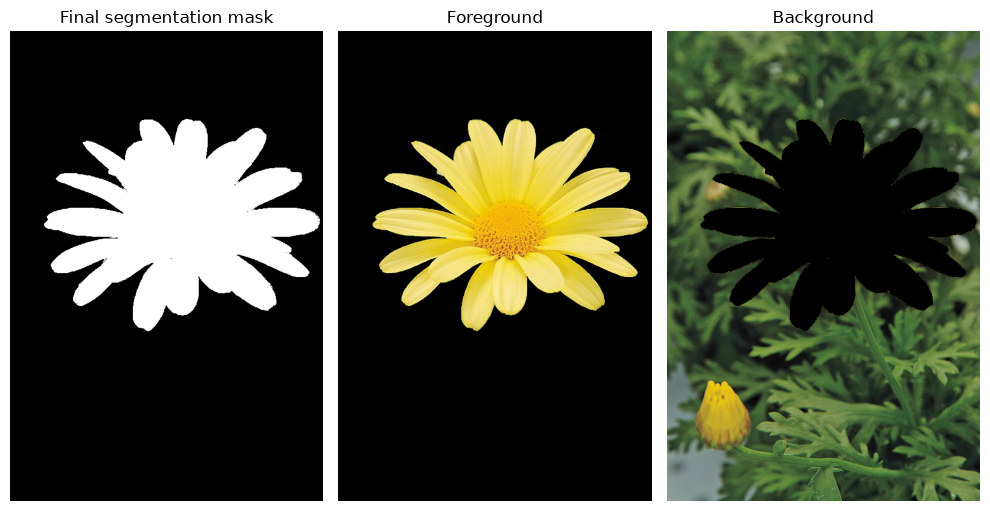

In [286]:
#Importing image
im_9 = cv.imread('Flower.jpg')

#Creating a blank mask
mask = np.zeros(im_9.shape[:2], np.uint8)

#For the use of grabCut alogorithm
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

#Selecting the rectangle
rect = (60, 60, 600, 550)

#grabCut
cv.grabCut(im_9, mask, rect, bgdModel, fgdModel, 5, cv.GC_INIT_WITH_RECT)

final_mask = np.where((mask == cv.GC_BGD) | (mask == cv.GC_PR_BGD), 0, 1).astype('uint8')

#Applying to the colour image
foreground = im_9 * final_mask[:, :, np.newaxis]

#For background
background_mask = 1 - final_mask

#Applying to the colour
background = im_9 * background_mask[:, :, np.newaxis]

#Display
fig, ax = plt.subplots(1, 3, figsize=(10, 5))

ax[0].imshow(final_mask, cmap='gray')
ax[0].set_title('Final segmentation mask')
ax[0].axis('off')

ax[1].imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
ax[1].set_title('Foreground')
ax[1].axis('off')

ax[2].imshow(cv.cvtColor(background, cv.COLOR_BGR2RGB))
ax[2].set_title('Background')
ax[2].axis('off')

plt.tight_layout()
plt.show()

$Q9)\ b)$

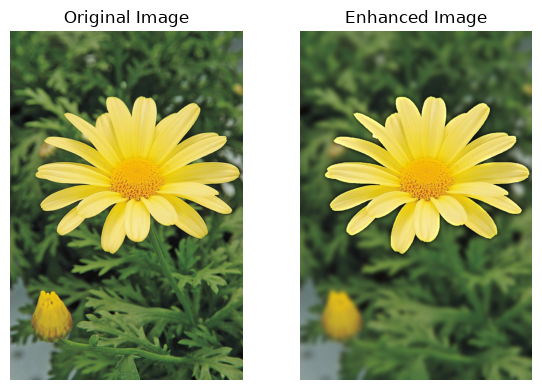

In [328]:
# Blurring the extracted background
blurred_background = cv.GaussianBlur(background, (31, 31), 0)

#Combining them
im_9_enhanced = cv.add(foreground, blurred_background)

#Diplaying
fig, ax = plt.subplots(1, 2, figsize=(6, 4))

ax[0].imshow(cv.cvtColor(im_9, cv.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(cv.cvtColor(im_9_enhanced, cv.COLOR_BGR2RGB))
ax[1].set_title('Enhanced Image')
ax[1].axis('off')

plt.tight_layout()
plt.show()


$Q9)\ c)\ \text{The dark region appears because pixels outside the segmented foreground are set to zero.}\\\text{During blurring, these zero-valued pixels contribute to the averaging near the flower boundary,}\\\text{reducing the intensity of nearby background pixels and producing a dark halo.}$ 

$Q10)\ a)$

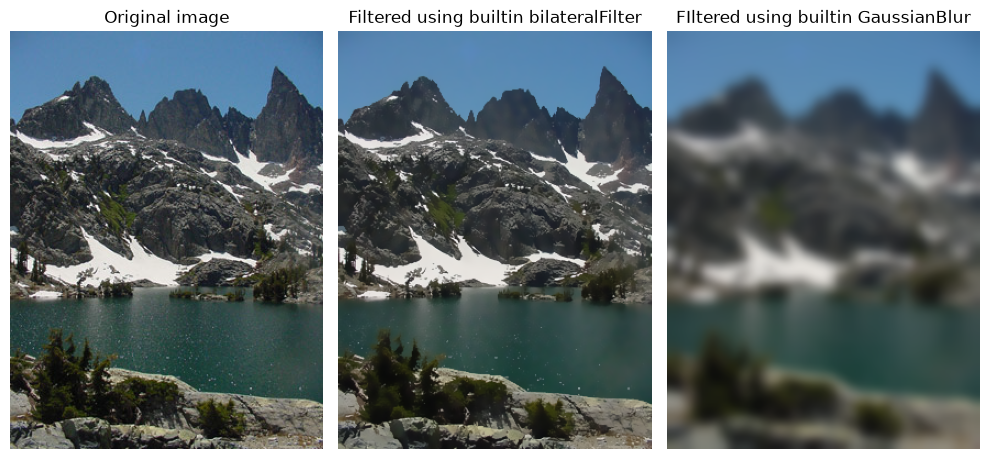

In [330]:
#Importing the image
im_10 = cv.imread('Lake.png')

#bilateral filter from opencCV
sigma_s = 31
sigma_r = 41
kernal_size = 9
im_10_bilateral_builtin = cv.bilateralFilter(im_10, kernal_size, sigma_r, sigma_s)

#Gaussian filtering from openCV
im_10_gaussian_builtin = cv.GaussianBlur(im_10, (sigma_s, sigma_s), 0)

#Display
fig, ax = plt.subplots(1, 3, figsize=(10, 5))

ax[0].imshow(cv.cvtColor(im_10, cv.COLOR_BGR2RGB))
ax[0].set_title('Original image')
ax[0].axis('off')

ax[1].imshow(cv.cvtColor(im_10_bilateral_builtin, cv.COLOR_BGR2RGB))
ax[1].set_title('Filtered using builtin bilateralFilter')
ax[1].axis('off')

ax[2].imshow(cv.cvtColor(im_10_gaussian_builtin, cv.COLOR_BGR2RGB))
ax[2].set_title('FIltered using builtin GaussianBlur')
ax[2].axis('off')

plt.tight_layout()
plt.show()

$Q10)\ b)$

MSE between OpenCV and created bilateral filter: 14.905589412126808


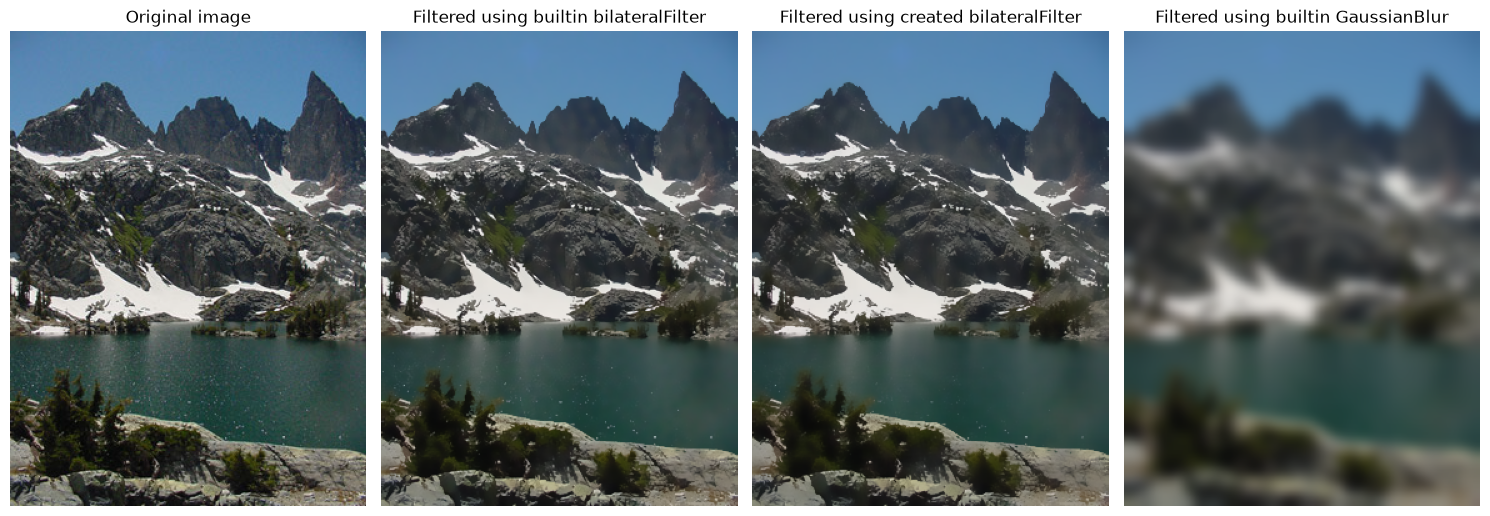

In [331]:
#Defining the function for bilateral filtering
def bilateral_filter(image, kernel_size, sigma_s, sigma_r):

    #Getting the height and width of the image
    h, w = image.shape[:2]

    #Converting the image to float to avoid overflow during calculations
    image_float = image.astype(np.float64)

    #Creating a blank image to store the filtered result
    filtered = np.zeros_like(image_float)

    #Getting the radius of the kernel
    radius = kernel_size // 2

    #Padding the image to handle border pixels
    padded = cv.copyMakeBorder(
        image_float, radius, radius, radius, radius, cv.BORDER_REFLECT)

    #Going through every pixel in the image
    for i in range(h):
        for j in range(w):

            #Getting the center pixel
            center_pixel = padded[i + radius, j + radius]

            #Variables for weighted sum and total weight
            weighted_sum = np.zeros(3, dtype=np.float64)

            total_weight = 0.0

            #Going through the neighborhood
            for m in range(-radius, radius + 1):
                for n in range(-radius, radius + 1):

                    #Getting the neighboring pixel
                    neighbor = padded[i + radius + m, j + radius + n]

                    #Spatial distance between the center pixel
                    #and the neighboring pixel
                    spatial_distance = m**2 + n**2

                    #Spatial Gaussian weight
                    spatial_weight = np.exp(-spatial_distance / (2 * sigma_s**2))

                    #Difference in intensity/color between
                    #the center and neighboring pixel
                    intensity_distance = np.sum((neighbor - center_pixel)**2)

                    #Range Gaussian weight
                    range_weight = np.exp(-intensity_distance / (2 * sigma_r**2))

                    #Final bilateral weight
                    weight = spatial_weight * range_weight

                    #Adding weighted neighboring pixel
                    weighted_sum += weight * neighbor

                    #Adding the weight
                    total_weight += weight

            #Normalizing by the total weight
            filtered[i, j] = weighted_sum / total_weight

    #Limiting the values to the valid image range
    filtered = np.clip(filtered, 0, 255)

    #Converting back to uint8
    return filtered.astype(np.uint8)

#From the created funtion
im_10_bilateral_created = bilateral_filter(im_10, kernal_size, sigma_s, sigma_r)

#Comparison
def mse(image1, image2):

    image1 = image1.astype(np.float64)
    image2 = image2.astype(np.float64)

    error = np.mean((image1 - image2) ** 2)

    return error

mse_value = mse(im_10_bilateral_builtin, im_10_bilateral_created)

print("MSE between OpenCV and created bilateral filter:", mse_value)

#Display
fig, ax = plt.subplots(1, 4, figsize=(15, 6))

ax[0].imshow(cv.cvtColor(im_10, cv.COLOR_BGR2RGB))
ax[0].set_title('Original image')
ax[0].axis('off')

ax[1].imshow(cv.cvtColor(im_10_bilateral_builtin, cv.COLOR_BGR2RGB))
ax[1].set_title('Filtered using builtin bilateralFilter')
ax[1].axis('off')

ax[2].imshow(cv.cvtColor(im_10_bilateral_created, cv.COLOR_BGR2RGB))
ax[2].set_title('Filtered using created bilateralFilter')
ax[2].axis('off')

ax[3].imshow(cv.cvtColor(im_10_gaussian_builtin, cv.COLOR_BGR2RGB))
ax[3].set_title('Filtered using builtin GaussianBlur')
ax[3].axis('off')


plt.tight_layout()

MSE between OpenCV and created bilateral filter: 14.905589412126808
